In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn import preprocessing
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier


from google.colab import files
uploaded = files.upload()

Saving credit_original data.csv to credit_original data.csv


In [ ]:
import pandas as pd
from io import StringIO

# Nếu file đã được upload
file_name = list(uploaded.keys())[0]  # Lấy tên file đầu tiên trong dictionary
dataframe = pd.read_csv(StringIO(uploaded[file_name].decode("utf-8")))  # Đọc file đúng cách
# Kiểm tra lại
dataframe.info()
dataframe.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203978 entries, 0 to 203977
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       202944 non-null  object 
 1   Customer ID                   202944 non-null  object 
 2   Loan Status                   202944 non-null  object 
 3   Current Loan Amount           202944 non-null  float64
 4   Term                          202944 non-null  object 
 5   Credit Score                  163927 non-null  float64
 6   Annual Income                 163927 non-null  float64
 7   Years in current job          194339 non-null  object 
 8   Home Ownership                202944 non-null  object 
 9   Purpose                       202944 non-null  object 
 10  Monthly Debt                  202944 non-null  float64
 11  Years of Credit History       202944 non-null  float64
 12  Months since last delinquent  94829 non-null

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.00,Short Term,709.00,1167493.00,8 years,Home Mortgage,Home Improvements,5214.74,17.20,NaN,6.00,1.00,228190.00,416746.00,1.00,0.00
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.00,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.10,8.00,35.00,0.00,229976.00,850784.00,0.00,0.00
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.00,Short Term,741.00,2231892.00,8 years,Own Home,Debt Consolidation,29200.53,14.90,29.00,18.00,1.00,297996.00,750090.00,0.00,0.00
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.00,Long Term,721.00,806949.00,3 years,Own Home,Debt Consolidation,8741.90,12.00,NaN,9.00,0.00,256329.00,386958.00,0.00,0.00
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.00,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.10,NaN,15.00,0.00,253460.00,427174.00,0.00,0.00


# **Thống kê mô tả**

In [ ]:
print("Number of rows:", dataframe.shape[0])
print("Number of columns:", dataframe.shape[1])

Number of rows: 203978
Number of columns: 19


In [ ]:
dataframe.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.00,Short Term,709.00,1167493.00,8 years,Home Mortgage,Home Improvements,5214.74,17.20,NaN,6.00,1.00,228190.00,416746.00,1.00,0.00
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.00,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.10,8.00,35.00,0.00,229976.00,850784.00,0.00,0.00
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.00,Short Term,741.00,2231892.00,8 years,Own Home,Debt Consolidation,29200.53,14.90,29.00,18.00,1.00,297996.00,750090.00,0.00,0.00
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.00,Long Term,721.00,806949.00,3 years,Own Home,Debt Consolidation,8741.90,12.00,NaN,9.00,0.00,256329.00,386958.00,0.00,0.00
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.00,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.10,NaN,15.00,0.00,253460.00,427174.00,0.00,0.00


In [ ]:
dataframe.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,202944.00,163927.00,163927.00,202944.00,202944.00,94829.00,202944.00,202944.00,202944.00,202941.00,202555.00,202926.00
mean,11690590.35,1076.48,1378168.75,18476.26,18.22,34.86,11.13,0.17,295129.00,754159.30,0.12,0.03
std,31698610.51,1475.25,1144831.17,12171.98,7.03,22.03,5.02,0.48,369081.77,7691813.59,0.35,0.26
min,10802.00,585.00,76627.00,0.00,3.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,179498.00,705.00,848692.00,10217.16,13.50,16.00,8.00,0.00,112765.00,274230.00,0.00,0.00
50%,312224.00,724.00,1173383.00,16230.56,16.90,32.00,10.00,0.00,210197.00,469106.00,0.00,0.00
75%,525316.00,741.00,1651993.00,23997.52,21.70,51.00,14.00,0.00,369170.00,786060.00,0.00,0.00
max,99999999.00,7510.00,165557393.00,435843.28,70.50,176.00,76.00,15.00,32878968.00,1539737892.00,7.00,15.00


In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203978 entries, 0 to 203977
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       202944 non-null  object 
 1   Customer ID                   202944 non-null  object 
 2   Loan Status                   202944 non-null  object 
 3   Current Loan Amount           202944 non-null  float64
 4   Term                          202944 non-null  object 
 5   Credit Score                  163927 non-null  float64
 6   Annual Income                 163927 non-null  float64
 7   Years in current job          194339 non-null  object 
 8   Home Ownership                202944 non-null  object 
 9   Purpose                       202944 non-null  object 
 10  Monthly Debt                  202944 non-null  float64
 11  Years of Credit History       202944 non-null  float64
 12  Months since last delinquent  94829 non-null

In [ ]:
dataframe.isnull().sum()

,0
Loan ID,1
Customer ID,1
Loan Status,1
Current Loan Amount,1
Term,1
Credit Score,19155
Annual Income,19155
Years in current job,3803
Home Ownership,1
Purpose,1


In [ ]:
dataframe.duplicated().sum()

0

<Axes: xlabel='Loan Status', ylabel='Density'>

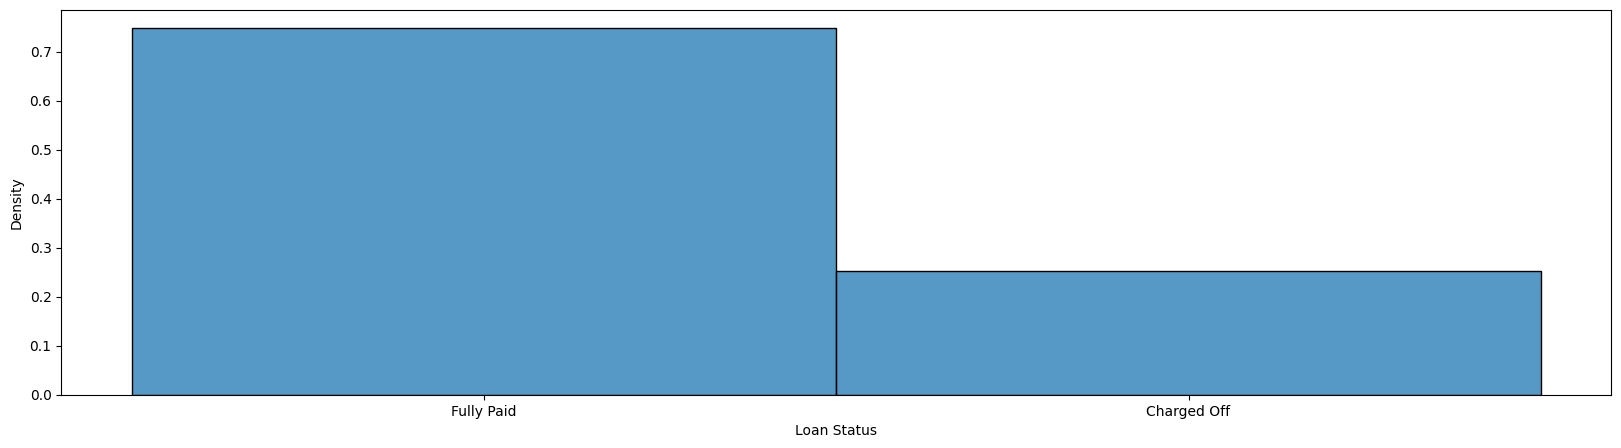

In [ ]:
plt.figure(figsize=(20, 5))
sns.histplot(dataframe['Loan Status'],label='with duplicate data',stat='density')

In [ ]:
dataframe= dataframe.drop_duplicates()

<Axes: xlabel='Loan Status', ylabel='Density'>

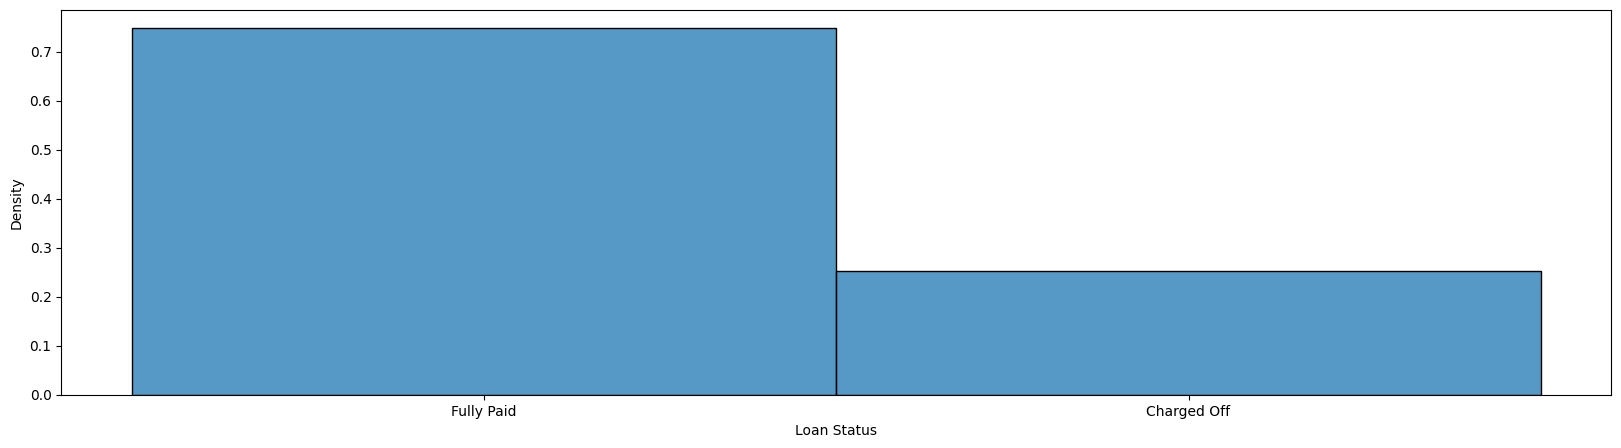

In [ ]:
plt.figure(figsize=(20, 5))
sns.histplot(dataframe['Loan Status'],label='without duplicate data',stat='density')

In [ ]:
dataframe_categorical= dataframe.select_dtypes(include='object')
dataframe_categorical.nunique()

,0
Loan ID,81999
Customer ID,81999
Loan Status,2
Term,2
Years in current job,11
Home Ownership,4
Purpose,16


# **Xử lý dữ liệu**

In [ ]:
dataframe.isnull().sum()/dataframe.shape[0]*100

,0
Loan ID,0.00
Customer ID,0.00
Loan Status,0.00
Current Loan Amount,0.00
Term,0.00
Credit Score,21.33
Annual Income,21.33
Years in current job,4.24
Home Ownership,0.00
Purpose,0.00



=> Tiến hành loại bỏ |các dữ liệu có tỷ lệ giá trị bị thiếu bé hơn 5%

In [ ]:
toBeDropped = []

for column in dataframe.columns:
    if (dataframe[column].isnull().sum() / dataframe.shape[0] * 100) < 5:
        toBeDropped.append(column)
toBeDropped

['Loan ID',
 'Customer ID',
 'Loan Status',
 'Current Loan Amount',
 'Term',
 'Years in current job',
 'Home Ownership',
 'Purpose',
 'Monthly Debt',
 'Years of Credit History',
 'Number of Open Accounts',
 'Number of Credit Problems',
 'Current Credit Balance',
 'Maximum Open Credit',
 'Bankruptcies',
 'Tax Liens']

In [ ]:
dataframe= dataframe.dropna(subset= toBeDropped)

In [ ]:
dataframe.isnull().sum()/dataframe.shape[0]*100

,0
Loan ID,0.00
Customer ID,0.00
Loan Status,0.00
Current Loan Amount,0.00
Term,0.00
Credit Score,21.33
Annual Income,21.33
Years in current job,0.00
Home Ownership,0.00
Purpose,0.00


=> Chỉ còn 3 biến "Credit Score", "Annual Income", "Months since last delinquent" cần phải xử lý giá trị bị thiếu (Missing value)


<Axes: >

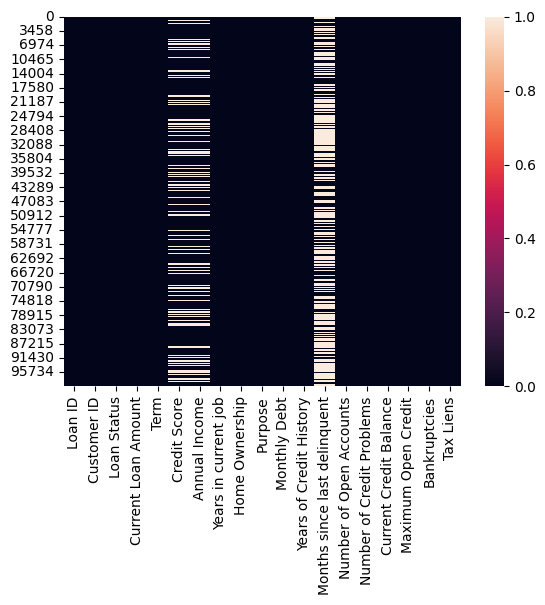

In [ ]:
sns.heatmap(dataframe.isnull())

# 1. Credit history

Có vấn đề ở "Credit Score", khi giá trị bình quân đạt 1125.57 trong khi giá trị credit score dù tính theo FICO Score hay VantageScore đều chỉ trong phạm vi 300-850. Do đó chúng ta tiến hành kiểm tra sai số trong biến "Credit Score".

In [ ]:
dataframe.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,85791.00,67490.00,67490.00,85791.00,85791.00,39506.00,85791.00,85791.00,85791.00,85791.00,85791.00,85791.00
mean,13128803.59,1125.57,1396654.33,18641.05,18.04,34.98,11.18,0.16,296282.13,774865.07,0.11,0.03
std,33366583.62,1561.60,1118572.24,12197.80,6.82,21.97,5.01,0.47,373701.49,8932842.16,0.34,0.25
min,15422.00,585.00,76627.00,0.00,3.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,185856.00,708.00,861640.50,10404.59,13.40,16.00,8.00,0.00,114627.00,279411.00,0.00,0.00
50%,320474.00,729.00,1198700.50,16363.56,16.90,32.00,10.00,0.00,212097.00,476476.00,0.00,0.00
75%,536206.00,742.00,1674774.00,24157.46,21.50,51.00,14.00,0.00,370775.50,795025.00,0.00,0.00
max,99999999.00,7510.00,165557393.00,435843.28,70.50,176.00,76.00,15.00,32878968.00,1539737892.00,7.00,15.00


In [ ]:
df = dataframe[dataframe['Credit Score']>800]
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
5,89d8cb0c-e5c2-4f54-b056-48a645c543dd,4ffe99d3-7f2a-44db-afc1-40943f1f9750,Charged Off,206602.00,Short Term,7290.00,896857.00,10+ years,Home Mortgage,Debt Consolidation,16367.74,17.30,NaN,6.00,0.00,215308.00,272448.00,0.00,0.00
43,0c84b81a-e5a9-4a92-8dc8-fb179add03a4,628b0914-b1d7-4028-b590-b50f5da53d06,Charged Off,288948.00,Short Term,7120.00,537472.00,10+ years,Rent,Debt Consolidation,5777.90,14.80,NaN,4.00,0.00,132468.00,164406.00,0.00,0.00
51,0daecc08-0354-4753-b282-52124b2420df,2884d362-391a-4941-af69-c825cae18002,Charged Off,219692.00,Long Term,6610.00,527839.00,10+ years,Rent,Debt Consolidation,14207.63,17.00,48.00,9.00,0.00,254277.00,379918.00,0.00,0.00
56,a5ada080-a058-4ad2-8953-002b7ec1ae31,9966e08c-04a6-41ab-86d0-e4062c64bd41,Charged Off,78012.00,Short Term,7380.00,728726.00,4 years,Rent,major_purchase,10135.36,11.40,NaN,8.00,0.00,104633.00,199936.00,0.00,0.00
65,1704367e-1d71-4551-8d33-49aa15cab4b1,88f97adf-070a-47b1-9657-38276eef7d19,Charged Off,523908.00,Long Term,7370.00,1028774.00,6 years,Home Mortgage,Debt Consolidation,22632.99,19.30,NaN,5.00,0.00,474658.00,742720.00,0.00,0.00


Có 5 dữ liệu bị sai số, giá trị sai số có xu hướng bị gấp 10 lần thực tế (có thể lúc nhập dữ liệu bị thừa 1 số 0). Tiến hành chia 10 để giá trị về đúng.

In [ ]:
dataframe['Credit Score'] = dataframe['Credit Score'].apply(lambda val: (val /10) if val>850 else val)
dataframe.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,85791.00,67490.00,67490.00,85791.00,85791.00,39506.00,85791.00,85791.00,85791.00,85791.00,85791.00,85791.00
mean,13128803.59,718.55,1396654.33,18641.05,18.04,34.98,11.18,0.16,296282.13,774865.07,0.11,0.03
std,33366583.62,28.18,1118572.24,12197.80,6.82,21.97,5.01,0.47,373701.49,8932842.16,0.34,0.25
min,15422.00,585.00,76627.00,0.00,3.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,185856.00,706.00,861640.50,10404.59,13.40,16.00,8.00,0.00,114627.00,279411.00,0.00,0.00
50%,320474.00,725.00,1198700.50,16363.56,16.90,32.00,10.00,0.00,212097.00,476476.00,0.00,0.00
75%,536206.00,740.00,1674774.00,24157.46,21.50,51.00,14.00,0.00,370775.50,795025.00,0.00,0.00
max,99999999.00,751.00,165557393.00,435843.28,70.50,176.00,76.00,15.00,32878968.00,1539737892.00,7.00,15.00


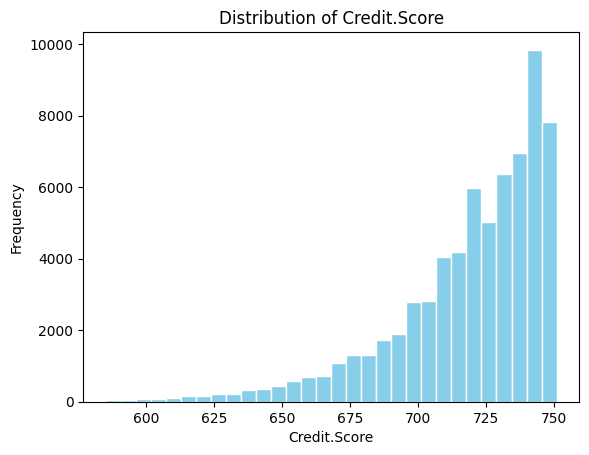

In [ ]:
import matplotlib.pyplot as plt

plt.hist(dataframe['Credit Score'], bins=30, color='skyblue', edgecolor='white')
plt.title("Distribution of Credit.Score")
plt.xlabel("Credit.Score")
plt.ylabel("Frequency")
plt.show()

Chỉ số bình quân (mean) đã về 718.55, phù hợp với thực tế

Tỷ lệ missing value > 5%, vì vậy không thể sử dụng phương pháp loại bỏ các giá trị bị thiếu, tránh ảnh hưởng đến toàn bộ dữ liệu. Vì vậy nhóm sử dụng phương pháp gán giá trị bằng cách tính trung bình (mean).
Nhóm nhận thấy không thể tính trung bình toàn bộ giá trị trong biến "Credit Score" bởi nhóm cho rằng điểm tín dụng của những người có khoản vay ngắn hạn sẽ không giống với điểm tín dụng của những người có khoản vay dài hạn. Do đó, nhóm lấy điểm tín dụng trung bình riêng của những người có khoản vay ngắn hạn và điểm tín dụng trung bình riêng của những người có khoản vay dài hạn, sau đó điền điểm tín dụng bị thiếu bằng cách tra cứu thời hạn của khoản vay.


In [ ]:
dataframe.dropna(subset=['Loan Status'], inplace = True)

Value counts for each term: 
 Term
Short Term    62621
Long Term     23170
Name: count, dtype: int64
Missing data in loan term: 0


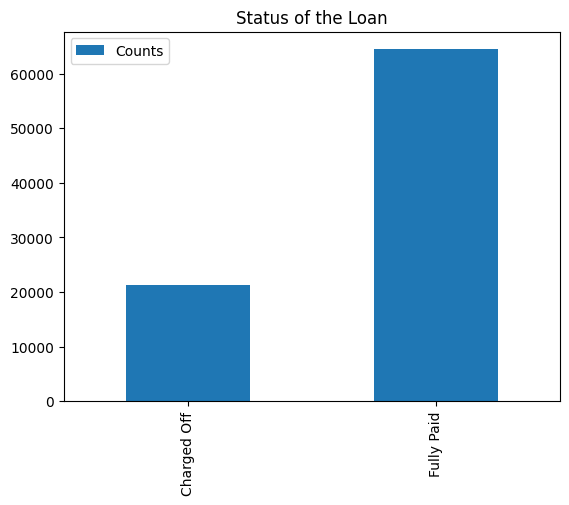

In [ ]:
le = preprocessing.LabelEncoder()
dataframe['Loan Status'] = le.fit_transform(dataframe['Loan Status'])
coffvalue = dataframe[dataframe['Loan Status'] == 0]['Loan Status'].count()
fpaidvalue = dataframe[dataframe['Loan Status'] == 1]['Loan Status'].count()
data = {"Counts":[coffvalue, fpaidvalue] }
statusDF = pd.DataFrame(data, index=["Charged Off", "Fully Paid"])
# statusDF.head()
statusDF.plot(kind='bar', title="Status of the Loan")
print("Value counts for each term: \n",dataframe['Term'].value_counts())
print("Missing data in loan term:",dataframe['Term'].isna().sum())

In [ ]:
dataframe['Term'].replace(("Short Term","Long Term"),(0,1), inplace=True)

<ipython-input-30-26320e1208a3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['Term'].replace(("Short Term","Long Term"),(0,1), inplace=True)
<ipython-input-30-26320e1208a3>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['Term'].replace(("Short Term","Long Term"),(0,1), inpl

In [ ]:
#Khoản vay ngắn hạn
cscoredf = dataframe[dataframe['Term']==0]
stermAVG = cscoredf['Credit Score'].mean()
print(stermAVG)

#Khoản vay dài hạn
lscoredf = dataframe[dataframe['Term']==1]
ltermAVG = lscoredf['Credit Score'].mean()
print(ltermAVG)

726.9090760324831
696.586195774875


In [ ]:
do_nothing = lambda: None
dataframe.loc[(dataframe.Term ==0) & (dataframe['Credit Score'].isnull()),'Credit Score'] = stermAVG
dataframe.loc[(dataframe.Term ==1) & (dataframe['Credit Score'].isnull()),'Credit Score'] = ltermAVG

Nhóm phân loại điểm tín dụng theo FICO SCore, cụ thể như sau:
* 300 - 579: Rất kém (Poor)
* 580 - 669: Trung bình (Fair)
* 670 - 739: Tốt (Good)
* 740 - 799: Rất tốt (Very Good)
* 800 - 850: Xuất sắc (Exceptional)

<Axes: title={'center': 'Number of loans in terms of Credit Score category'}, xlabel='Credit Score'>

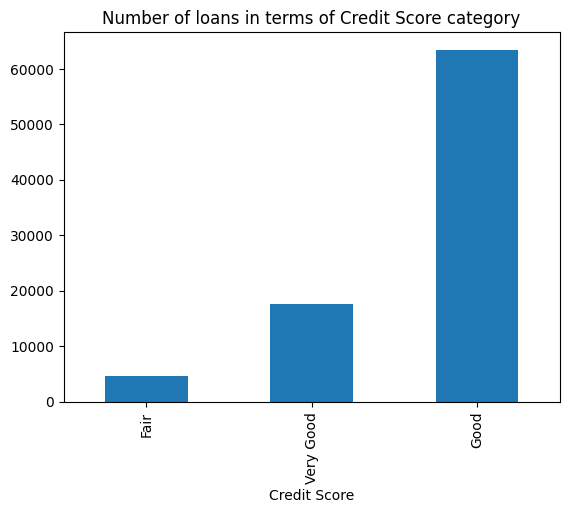

In [ ]:
dataframe['Credit Score'] = dataframe['Credit Score'].apply(lambda val: "Poor" if np.isreal(val) and val < 580 else val)
dataframe['Credit Score'] = dataframe['Credit Score'].apply(lambda val: "Fair" if np.isreal(val) and (val >= 580 and val < 670) else val)
dataframe['Credit Score'] = dataframe['Credit Score'].apply(lambda val: "Good" if np.isreal(val) and (val >= 670 and val < 740) else val)
dataframe['Credit Score'] = dataframe['Credit Score'].apply(lambda val: "Very Good" if np.isreal(val) and (val >= 740 and val < 800) else val)
dataframe['Credit Score'] = dataframe['Credit Score'].apply(lambda val: "Exceptional" if np.isreal(val) and (val >= 800 and val <= 850) else val)
dataframe['Credit Score'].value_counts().sort_values(ascending = True).plot(kind='bar', title ='Number of loans in terms of Credit Score category')

Khi xử lý Credit Score, nhóm chuyển nó thành giá trị rời rạc và do có nhiều lớp nên sử dụng one-hot encoding kèm theo việc loại bỏ một biến (vì giá trị của biến đó có thể suy ra từ các biến còn lại) nhằm tránh tăng số chiều dữ liệu và giảm thiểu đa cộng tuyến, phương pháp này được áp dụng nhất quán trong toàn bộ bài phân tích.

In [ ]:
dataframe = dataframe.join(pd.get_dummies(dataframe['Credit Score'], drop_first = True))
dataframe.rename(index = str, columns={'Good':'Credit Good', 'Very Good':'Credit Very Good'})
dataframe = dataframe.drop(['Credit Score'], axis=1)

In [ ]:
dataframe['Good'] = dataframe['Good'].astype(int)
dataframe['Very Good'] = dataframe['Very Good'].astype(int)
dataframe.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Good,Very Good
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,1,445412.00,0,1167493.00,8 years,Home Mortgage,Home Improvements,5214.74,17.20,NaN,6.00,1.00,228190.00,416746.00,1.00,0.00,1,0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,1,262328.00,0,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.10,8.00,35.00,0.00,229976.00,850784.00,0.00,0.00,1,0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,1,99999999.00,0,2231892.00,8 years,Own Home,Debt Consolidation,29200.53,14.90,29.00,18.00,1.00,297996.00,750090.00,0.00,0.00,0,1
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,1,347666.00,1,806949.00,3 years,Own Home,Debt Consolidation,8741.90,12.00,NaN,9.00,0.00,256329.00,386958.00,0.00,0.00,1,0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,1,176220.00,0,NaN,5 years,Rent,Debt Consolidation,20639.70,6.10,NaN,15.00,0.00,253460.00,427174.00,0.00,0.00,1,0


Những khách hàng có giá trị 0 ở cả biến Good và biến Very Good thì sẽ được hiểu là có điểm tín dụng ở mức "Fair"

# Annual Income

In [ ]:
dataframe.describe()

,Loan Status,Current Loan Amount,Term,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Good,Very Good
count,85791.00,85791.00,85791.00,67490.00,85791.00,85791.00,39506.00,85791.00,85791.00,85791.00,85791.00,85791.00,85791.00,85791.00,85791.00
mean,0.75,13128803.59,0.27,1396654.33,18641.05,18.04,34.98,11.18,0.16,296282.13,774865.07,0.11,0.03,0.74,0.21
std,0.43,33366583.62,0.44,1118572.24,12197.80,6.82,21.97,5.01,0.47,373701.49,8932842.16,0.34,0.25,0.44,0.40
min,0.00,15422.00,0.00,76627.00,0.00,3.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,185856.00,0.00,861640.50,10404.59,13.40,16.00,8.00,0.00,114627.00,279411.00,0.00,0.00,0.00,0.00
50%,1.00,320474.00,0.00,1198700.50,16363.56,16.90,32.00,10.00,0.00,212097.00,476476.00,0.00,0.00,1.00,0.00
75%,1.00,536206.00,1.00,1674774.00,24157.46,21.50,51.00,14.00,0.00,370775.50,795025.00,0.00,0.00,1.00,0.00
max,1.00,99999999.00,1.00,165557393.00,435843.28,70.50,176.00,76.00,15.00,32878968.00,1539737892.00,7.00,15.00,1.00,1.00


<ipython-input-37-8fec6e099480>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_nonnull['AnnualIncome_log'] = np.log(dataframe_nonnull['Annual Income'])


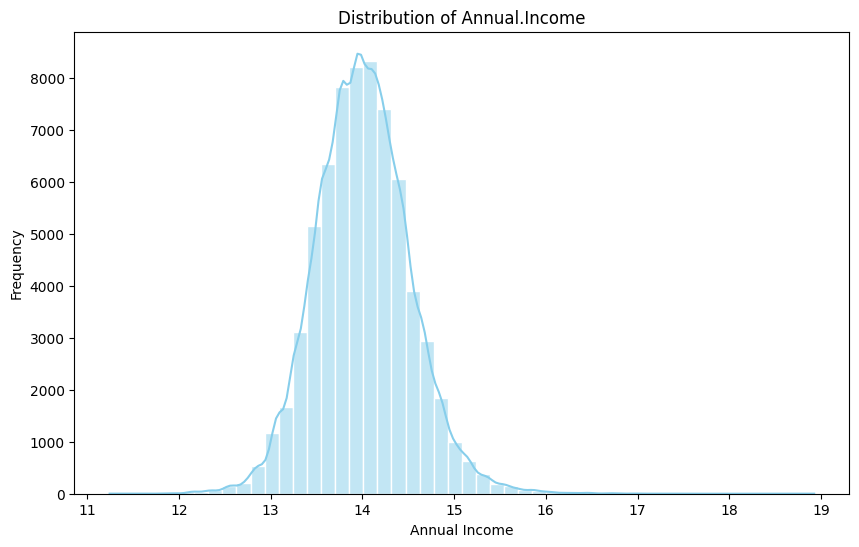

Skewness of Annual.Income: 50.3635937541244


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử DataFrame là `df` và cột Annual.Income không có missing value
# Nếu có missing value, hãy loại bỏ hoặc xử lý trước:
dataframe_nonnull = dataframe.dropna(subset=['Annual Income'])
dataframe_nonnull['AnnualIncome_log'] = np.log(dataframe_nonnull['Annual Income'])

plt.figure(figsize=(10, 6))
sns.histplot(dataframe_nonnull['AnnualIncome_log'],
             bins=50,            # Số bin tùy chỉnh để hiển thị rõ hơn
             kde=True,           # Vẽ thêm đường KDE
             color='skyblue',
             edgecolor='white')
plt.title("Distribution of Annual.Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

# Tính độ lệch (skewness) để kiểm tra dữ liệu lệch phải (positive) hay lệch trái (negative)
skew_val = dataframe_nonnull['Annual Income'].skew()
print(f"Skewness of Annual.Income: {skew_val}")

In [ ]:
dataframe['Annual Income'].mode()

,Annual Income
0,1162572.00


In [ ]:
dataframe['Annual Income'] = dataframe['Annual Income'].fillna(dataframe['Annual Income'].mode()[0])
dataframe.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Good,Very Good
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,1,445412.00,0,1167493.00,8 years,Home Mortgage,Home Improvements,5214.74,17.20,NaN,6.00,1.00,228190.00,416746.00,1.00,0.00,1,0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,1,262328.00,0,1162572.00,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.10,8.00,35.00,0.00,229976.00,850784.00,0.00,0.00,1,0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,1,99999999.00,0,2231892.00,8 years,Own Home,Debt Consolidation,29200.53,14.90,29.00,18.00,1.00,297996.00,750090.00,0.00,0.00,0,1
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,1,347666.00,1,806949.00,3 years,Own Home,Debt Consolidation,8741.90,12.00,NaN,9.00,0.00,256329.00,386958.00,0.00,0.00,1,0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,1,176220.00,0,1162572.00,5 years,Rent,Debt Consolidation,20639.70,6.10,NaN,15.00,0.00,253460.00,427174.00,0.00,0.00,1,0


# Months since last delinquent

In [ ]:
missing_percentage = (dataframe['Months since last delinquent'].isna().sum() / len(dataframe)) * 100
print(f"Tỷ lệ missing values của biến: {missing_percentage:.2f}%")

Tỷ lệ missing values của biến: 53.95%


Tỷ lệ missing value của biến "Months since last deliquent" đạt 53.7%, do đó nhóm quyết định loại bỏ biến này

In [ ]:
dataframe = dataframe.drop(['Months since last delinquent'],axis=1)

In [ ]:
# Kiểm tra tổng số giá trị null trong mỗi cột
null_counts = dataframe.isnull().sum()

# Lọc ra các cột có ít nhất một giá trị null
null_counts = null_counts[null_counts > 0]

# In kết quả
if null_counts.empty:
    print("✅ Không có giá trị null trong dataframe.")
else:
    print("⚠️ Các cột có giá trị null:")
    print(null_counts)

✅ Không có giá trị null trong dataframe.


**=> Đã xử lý xong các giá trị bị thiếu**

# **Trực quan hóa phân bố dữ liệu bằng pairplot**

In [ ]:
dataframe_numerical = dataframe.select_dtypes(include=['float64']).drop(columns=['Bankruptcies'])
print(dataframe_numerical.shape)

(85791, 9)


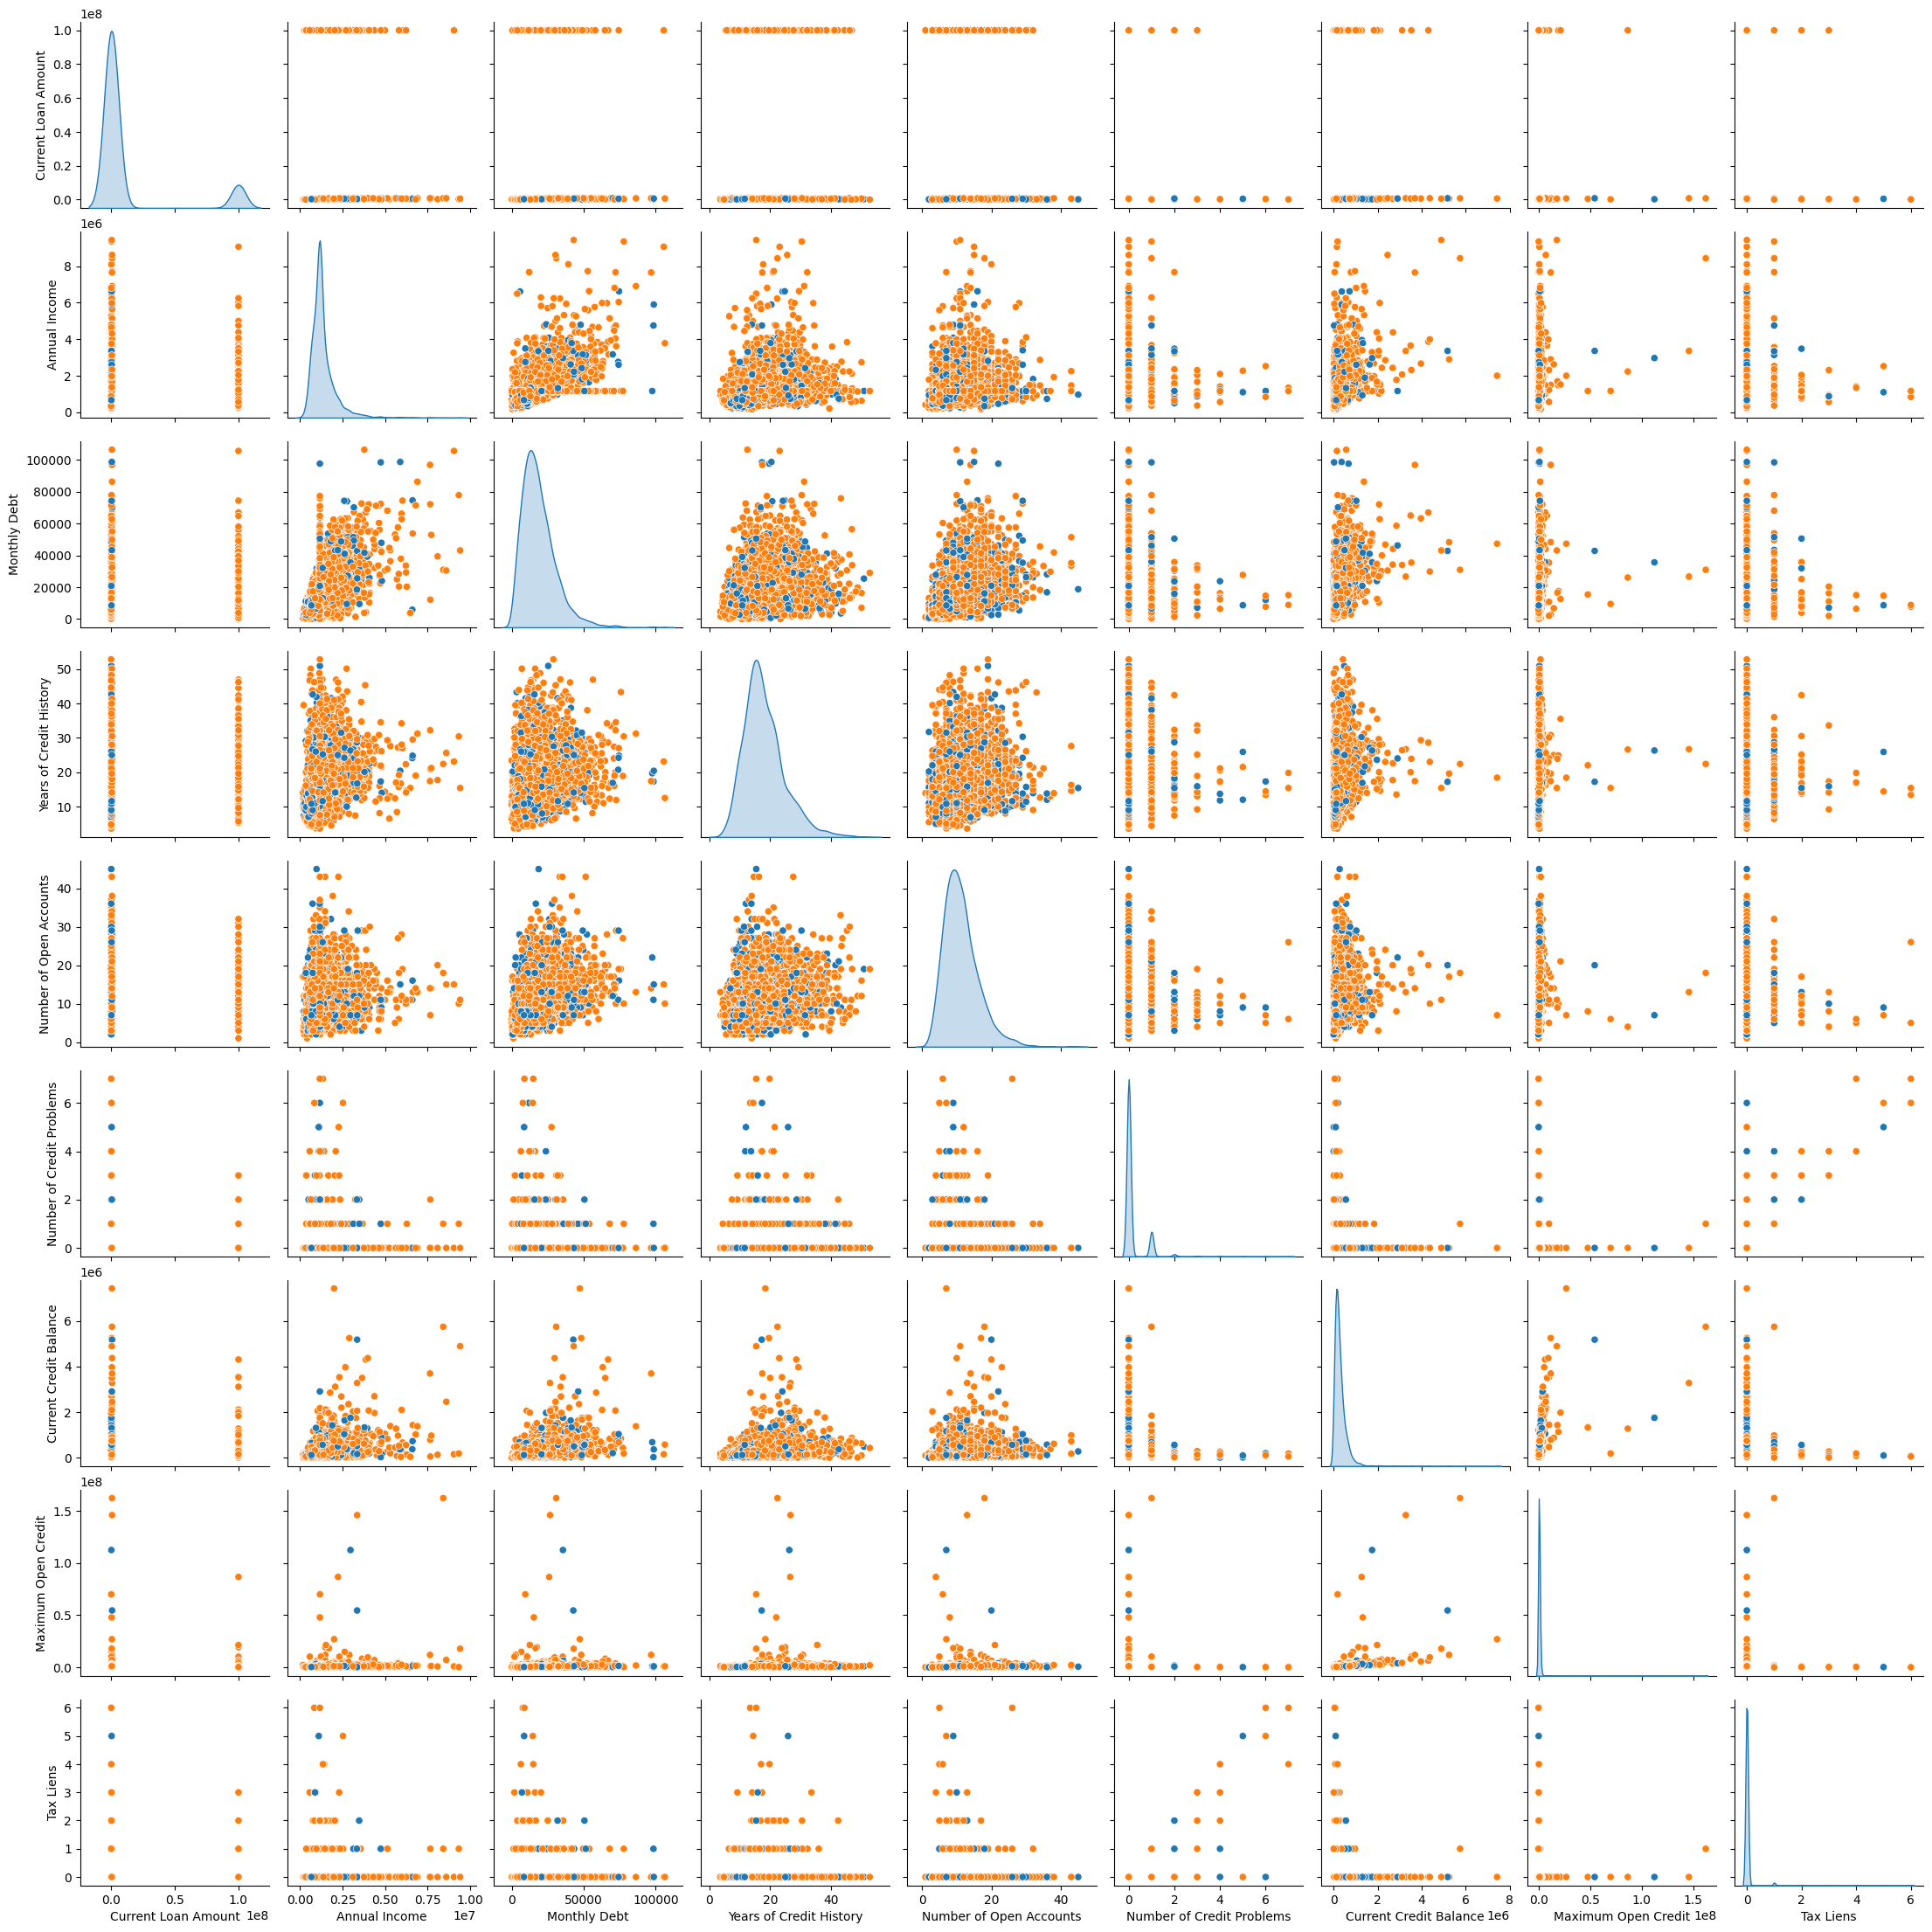

In [ ]:
sns.pairplot(dataframe_numerical.iloc[:5000,:], diag_kind='kde', plot_kws={'hue': dataframe['Loan Status']})

In [ ]:
dataframe.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Annual Income', 'Years in current job', 'Home Ownership', 'Purpose',
       'Monthly Debt', 'Years of Credit History', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens', 'Good',
       'Very Good'],
      dtype='object')

In [ ]:
dataframe.drop(['Loan ID','Customer ID'],axis=1, inplace = True)

# Mô tả 1 số biến

<Axes: title={'center': 'Purpose for Loans'}, ylabel='Purpose'>

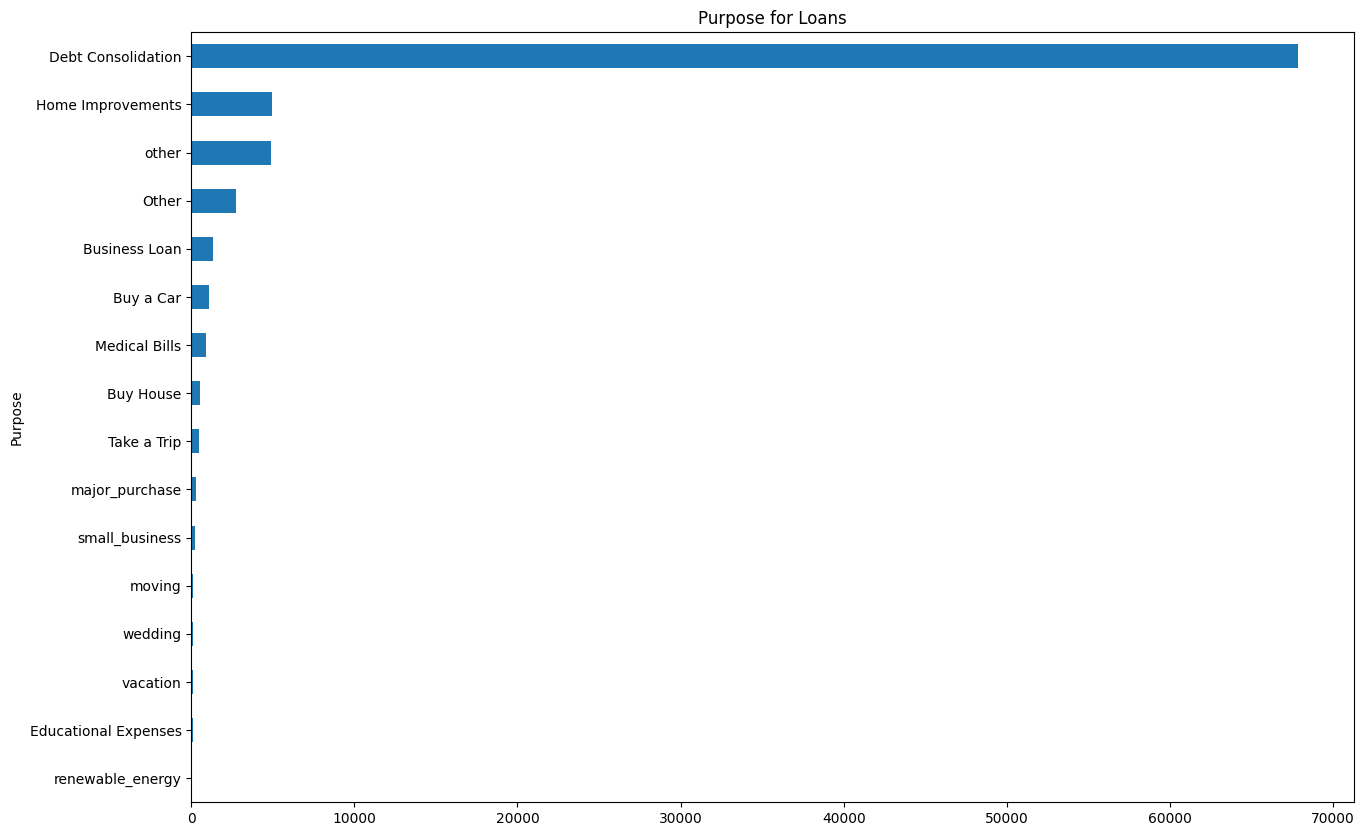

In [ ]:
dataframe['Purpose'].value_counts().sort_values(ascending=True).plot(kind='barh', title="Purpose for Loans", figsize=(15,10))

<Axes: title={'center': 'Purpose of Loan Vs Loan Payment Status'}, xlabel='Purpose'>

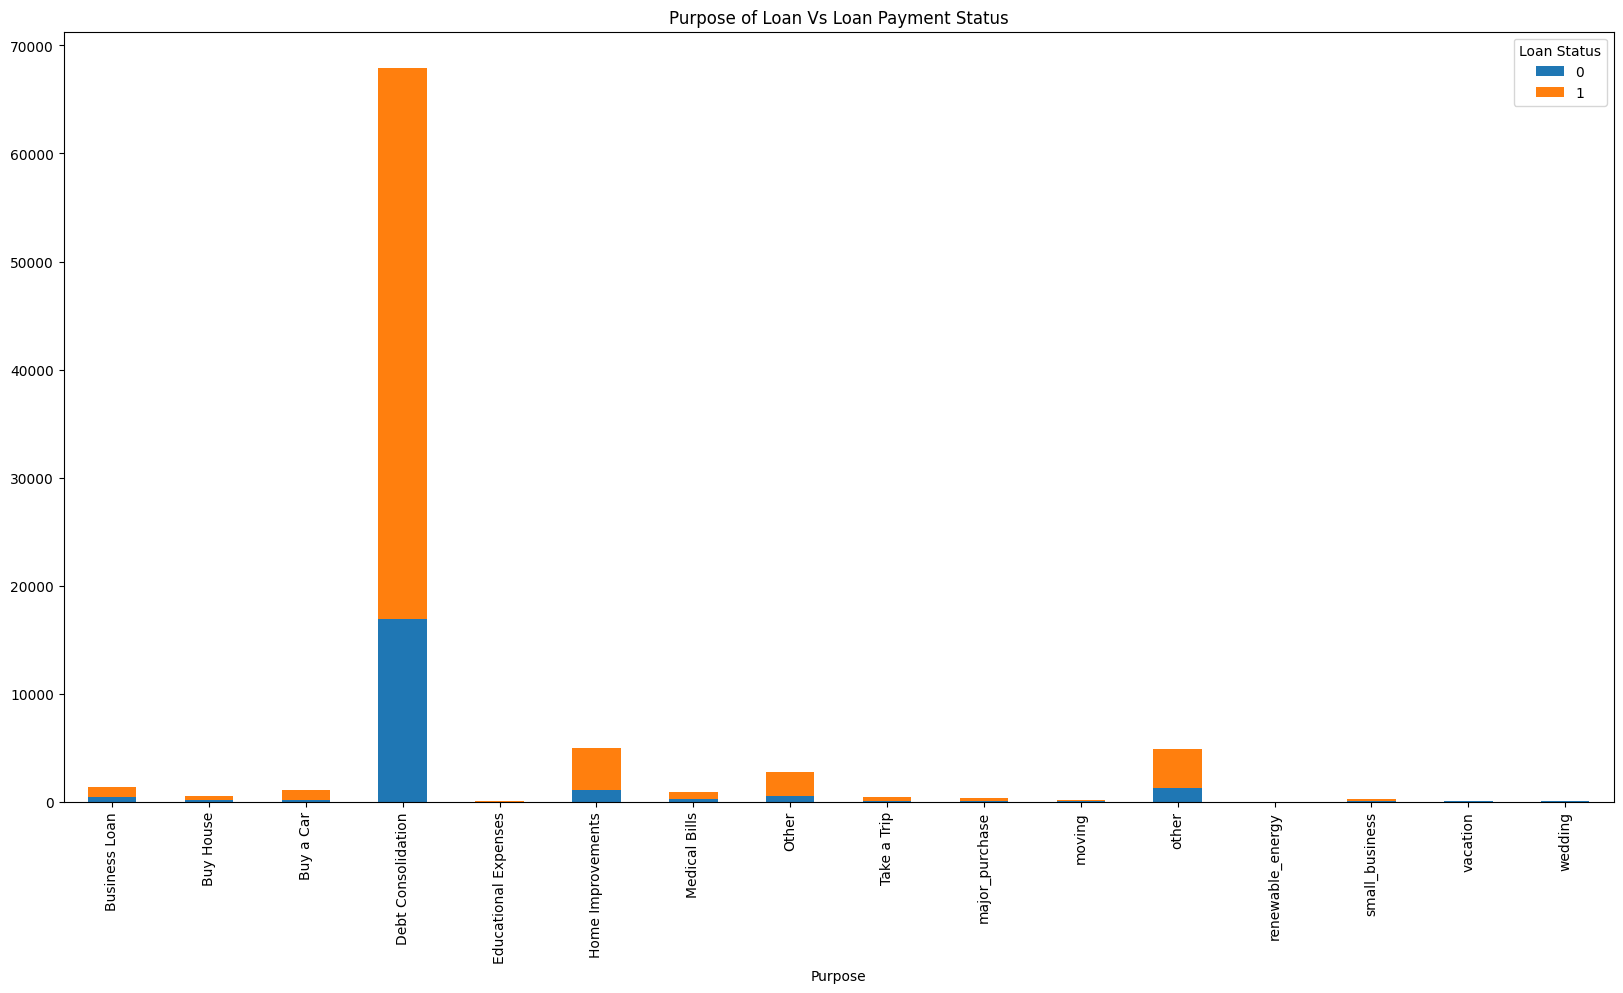

In [ ]:
purposeloanstatus = dataframe[['Purpose','Loan Status']]
purposeloanstatus.head()
pd.crosstab(purposeloanstatus['Purpose'], purposeloanstatus['Loan Status']).plot(kind='bar', stacked=True, figsize=(20,10), title="Purpose of Loan Vs Loan Payment Status", )

=> Phần lớn người đi vay với mục đích trả nợ (Giải thích thuật ngữ debt consolidation là gì)

<Axes: title={'center': 'Number of Loan based on Home ownership'}, xlabel='Home Ownership'>

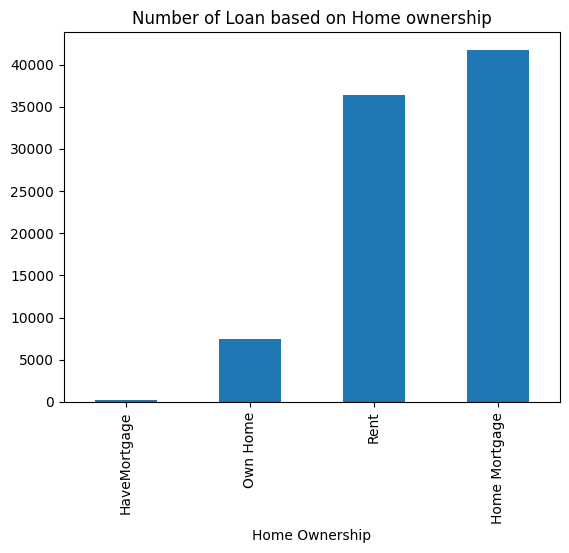

In [ ]:
dataframe['Home Ownership'].value_counts().sort_values(ascending = True).plot(kind='bar', title="Number of Loan based on Home ownership")

-> Phần lớn khoản vay đều đến từ những người đang thuê nhà hoặc đang thế chấp nhà

In [ ]:
dataframe = dataframe.join(pd.get_dummies(dataframe['Home Ownership'],drop_first = True))
dataframe = dataframe.drop(['Home Ownership'], axis=1)

Tiếp theo, số năm làm việc là một trong những yếu tố quan trọng quyết định sự ổn định tài chính và nguồn thu nhập an toàn của cá nhân; do dữ liệu ban đầu là chuỗi và phân bố không đồng đều, nên nhóm cần trích xuất và chuẩn hóa các khoảng giá trị để chuyển đổi thành biến phân loại.









In [ ]:
dataframe['Years in current job']=dataframe['Years in current job'].str.extract(r"(\d+)")
dataframe['Years in current job'] = dataframe['Years in current job'].astype(float)
expmean = dataframe['Years in current job'].mean()
dataframe['Years in current job'].fillna(expmean, inplace=True)

<ipython-input-51-fcd5c6f1159c>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe['Years in current job'].fillna(expmean, inplace=True)


Dựa trên thực tế mức độ kinh nghiệm trong thị trường lao động Mỹ, có thể phân chia cấp bậc nhân sự theo số năm kinh nghiệm như sau:
1. Junior Level ("Emp Level Jr."): 0-3 năm
2. Mid-Level ("Emp Level Mid."): 4-7 năm
3. Senior Level ("Emp Senior"): 8+ năm

In [ ]:
dataframe['Employment History'] = dataframe['Years in current job'].apply(lambda x: "Emp Level Jr." if x<4 else ("Emp Level Mid" if x>4 and x<8 else "Emp Senior"))

In [ ]:
dataframe = dataframe.drop(['Years in current job'], axis=1)
dataframe = dataframe.join(pd.get_dummies(dataframe['Employment History'],drop_first = True))
dataframe = dataframe.drop(['Employment History'], axis=1)

In [ ]:
dataframe.head()

,Loan Status,Current Loan Amount,Term,Annual Income,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Good,Very Good,Home Mortgage,Own Home,Rent,Emp Level Mid,Emp Senior
0,1,445412.00,0,1167493.00,Home Improvements,5214.74,17.20,6.00,1.00,228190.00,416746.00,1.00,0.00,1,0,True,False,False,False,True
1,1,262328.00,0,1162572.00,Debt Consolidation,33295.98,21.10,35.00,0.00,229976.00,850784.00,0.00,0.00,1,0,True,False,False,False,True
2,1,99999999.00,0,2231892.00,Debt Consolidation,29200.53,14.90,18.00,1.00,297996.00,750090.00,0.00,0.00,0,1,False,True,False,False,True
3,1,347666.00,1,806949.00,Debt Consolidation,8741.90,12.00,9.00,0.00,256329.00,386958.00,0.00,0.00,1,0,False,True,False,False,False
4,1,176220.00,0,1162572.00,Debt Consolidation,20639.70,6.10,15.00,0.00,253460.00,427174.00,0.00,0.00,1,0,False,False,True,True,False


Tiếp theo, số lượng vấn đề tín dụng được báo cáo cho từng người vay được nhóm thành ba danh mục: 0 là không có vấn đề, từ 1 đến 5 là có một số vấn đề, và hơn 5 là gặp vấn đề tín dụng nghiêm trọng.









In [ ]:
dataframe['Credit Problems'] = dataframe['Number of Credit Problems'].apply(lambda x: "No Credit Problem" if x==0 else ("Some Credit promblem" if x>0 and x<5 else "Major Credit Problems"))
dataframe['Credit Problems'].value_counts()

,count
Credit Problems,
No Credit Problem,74430
Some Credit promblem,11292
Major Credit Problems,69


<Axes: title={'center': 'Loans vs Credit problems of Loanee'}, ylabel='Credit Problems'>

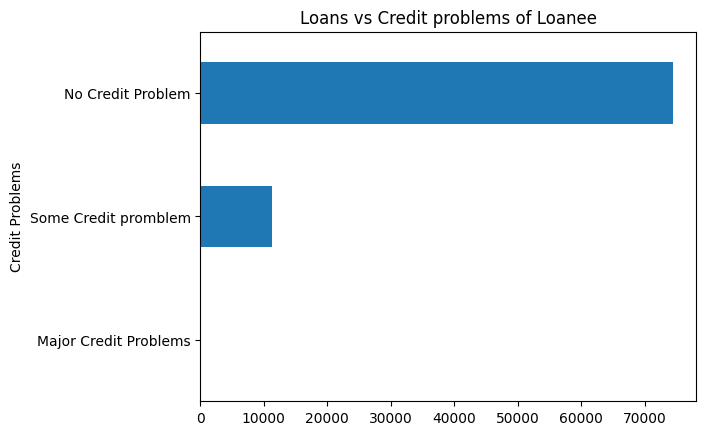

In [ ]:
dataframe['Credit Problems'].value_counts().sort_values(ascending=True).plot(kind='barh', title="Loans vs Credit problems of Loanee")

Nhìn vào biểu đồ trên, nhóm đưa ra một giả định rằng các khoản vay thường không được cấp cho những người có vấn đề về tín dụng. Tiếp theo, nhóm chuyển đổi Vấn đề tín dụng thành các biến rời rạc.


In [ ]:
dataframe = dataframe.join(pd.get_dummies(dataframe['Credit Problems'],drop_first = True))
dataframe = dataframe.drop(['Credit Problems','Number of Credit Problems'], axis=1)

In [ ]:
dataframe.head()

,Loan Status,Current Loan Amount,Term,Annual Income,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Current Credit Balance,Maximum Open Credit,...,Tax Liens,Good,Very Good,Home Mortgage,Own Home,Rent,Emp Level Mid,Emp Senior,No Credit Problem,Some Credit promblem
0,1,445412.00,0,1167493.00,Home Improvements,5214.74,17.20,6.00,228190.00,416746.00,...,0.00,1,0,True,False,False,False,True,False,True
1,1,262328.00,0,1162572.00,Debt Consolidation,33295.98,21.10,35.00,229976.00,850784.00,...,0.00,1,0,True,False,False,False,True,True,False
2,1,99999999.00,0,2231892.00,Debt Consolidation,29200.53,14.90,18.00,297996.00,750090.00,...,0.00,0,1,False,True,False,False,True,False,True
3,1,347666.00,1,806949.00,Debt Consolidation,8741.90,12.00,9.00,256329.00,386958.00,...,0.00,1,0,False,True,False,False,False,True,False
4,1,176220.00,0,1162572.00,Debt Consolidation,20639.70,6.10,15.00,253460.00,427174.00,...,0.00,1,0,False,False,True,True,False,True,False


Một đặc trưng quan trọng khác để xác định sự ổn định tài chính là số năm có lịch sử tín dụng; nhóm xem xét độ tuổi tín dụng của từng cá nhân và chuyển đổi nó thành các danh mục thông qua one-hot encoding.









In [ ]:
dataframe['Credit Age'] = dataframe['Years of Credit History'].apply(lambda x: "Short Credit Age" if x<5 else ("Good Credit Age" if x>5 and x<17 else "Exceptional Credit Age"))
dataframe = dataframe.join(pd.get_dummies(dataframe['Credit Age'],drop_first = True))
dataframe = dataframe.drop(['Credit Age','Years of Credit History'], axis =1)
dataframe.head()

,Loan Status,Current Loan Amount,Term,Annual Income,Purpose,Monthly Debt,Number of Open Accounts,Current Credit Balance,Maximum Open Credit,Bankruptcies,...,Very Good,Home Mortgage,Own Home,Rent,Emp Level Mid,Emp Senior,No Credit Problem,Some Credit promblem,Good Credit Age,Short Credit Age
0,1,445412.00,0,1167493.00,Home Improvements,5214.74,6.00,228190.00,416746.00,1.00,...,0,True,False,False,False,True,False,True,False,False
1,1,262328.00,0,1162572.00,Debt Consolidation,33295.98,35.00,229976.00,850784.00,0.00,...,0,True,False,False,False,True,True,False,False,False
2,1,99999999.00,0,2231892.00,Debt Consolidation,29200.53,18.00,297996.00,750090.00,0.00,...,1,False,True,False,False,True,False,True,True,False
3,1,347666.00,1,806949.00,Debt Consolidation,8741.90,9.00,256329.00,386958.00,0.00,...,0,False,True,False,False,False,True,False,True,False
4,1,176220.00,0,1162572.00,Debt Consolidation,20639.70,15.00,253460.00,427174.00,0.00,...,0,False,False,True,True,False,True,False,True,False


Để tìm hiểu sâu hơn về sự ổn định tài chính của bên vay, nhóm sẽ xem xét số lượng tài sản thế chấp của họ, từ đó cung cấp cho chúng ta thông tin về các cam kết trước đây của họ.

> Thêm khối trích dẫn




In [ ]:
dataframe['Tax Liens'] = dataframe['Tax Liens'].apply(lambda x: "No Tax Lien" if x==0 else ("Some Tax Liens" if x>0 and x<3 else "Many Tax Liens"))
dataframe = dataframe.join(pd.get_dummies(dataframe['Tax Liens'],drop_first = True))

In [ ]:
dataframe = dataframe.drop(['Tax Liens'],axis=1)
dataframe.head()

,Loan Status,Current Loan Amount,Term,Annual Income,Purpose,Monthly Debt,Number of Open Accounts,Current Credit Balance,Maximum Open Credit,Bankruptcies,...,Own Home,Rent,Emp Level Mid,Emp Senior,No Credit Problem,Some Credit promblem,Good Credit Age,Short Credit Age,No Tax Lien,Some Tax Liens
0,1,445412.00,0,1167493.00,Home Improvements,5214.74,6.00,228190.00,416746.00,1.00,...,False,False,False,True,False,True,False,False,True,False
1,1,262328.00,0,1162572.00,Debt Consolidation,33295.98,35.00,229976.00,850784.00,0.00,...,False,False,False,True,True,False,False,False,True,False
2,1,99999999.00,0,2231892.00,Debt Consolidation,29200.53,18.00,297996.00,750090.00,0.00,...,True,False,False,True,False,True,True,False,True,False
3,1,347666.00,1,806949.00,Debt Consolidation,8741.90,9.00,256329.00,386958.00,0.00,...,True,False,False,False,True,False,True,False,True,False
4,1,176220.00,0,1162572.00,Debt Consolidation,20639.70,15.00,253460.00,427174.00,0.00,...,False,True,True,False,True,False,True,False,True,False


In [ ]:
dataframe['Purpose'] = le.fit_transform(dataframe['Purpose'])
dataframe = dataframe.astype({col: int for col in dataframe.select_dtypes(include=bool).columns})

In [ ]:
dataframe.head()

,Loan Status,Current Loan Amount,Term,Annual Income,Purpose,Monthly Debt,Number of Open Accounts,Current Credit Balance,Maximum Open Credit,Bankruptcies,...,Own Home,Rent,Emp Level Mid,Emp Senior,No Credit Problem,Some Credit promblem,Good Credit Age,Short Credit Age,No Tax Lien,Some Tax Liens
0,1,445412.00,0,1167493.00,5,5214.74,6.00,228190.00,416746.00,1.00,...,0,0,0,1,0,1,0,0,1,0
1,1,262328.00,0,1162572.00,3,33295.98,35.00,229976.00,850784.00,0.00,...,0,0,0,1,1,0,0,0,1,0
2,1,99999999.00,0,2231892.00,3,29200.53,18.00,297996.00,750090.00,0.00,...,1,0,0,1,0,1,1,0,1,0
3,1,347666.00,1,806949.00,3,8741.90,9.00,256329.00,386958.00,0.00,...,1,0,0,0,1,0,1,0,1,0
4,1,176220.00,0,1162572.00,3,20639.70,15.00,253460.00,427174.00,0.00,...,0,1,1,0,1,0,1,0,1,0


In [ ]:
dataframe['Bankruptcies_final'] = dataframe['Bankruptcies'].apply(lambda x: "No Bankruptcies" if x == 0 else ("Some Bankruptcies" if 0 < x < 4 else "Many Bankruptcies"))
dataframe.drop(columns=['Bankruptcies'], inplace=True)  # Xóa cột gốc

In [ ]:
dataframe['Bankruptcies_final'] = dataframe['Bankruptcies_final'].map({
    "No Bankruptcies": 0,
    "Some Bankruptcies": 1,
    "Many Bankruptcies": 2
})

In [ ]:
dataframe.head()

,Loan Status,Current Loan Amount,Term,Annual Income,Purpose,Monthly Debt,Number of Open Accounts,Current Credit Balance,Maximum Open Credit,Good,...,Rent,Emp Level Mid,Emp Senior,No Credit Problem,Some Credit promblem,Good Credit Age,Short Credit Age,No Tax Lien,Some Tax Liens,Bankruptcies_final
0,1,445412.00,0,1167493.00,5,5214.74,6.00,228190.00,416746.00,1,...,0,0,1,0,1,0,0,1,0,1
1,1,262328.00,0,1162572.00,3,33295.98,35.00,229976.00,850784.00,1,...,0,0,1,1,0,0,0,1,0,0
2,1,99999999.00,0,2231892.00,3,29200.53,18.00,297996.00,750090.00,0,...,0,0,1,0,1,1,0,1,0,0
3,1,347666.00,1,806949.00,3,8741.90,9.00,256329.00,386958.00,1,...,0,0,0,1,0,1,0,1,0,0
4,1,176220.00,0,1162572.00,3,20639.70,15.00,253460.00,427174.00,1,...,1,1,0,1,0,1,0,1,0,0


=> Đã xử lý xong dữ liệu

# **=> Lựa chọn mô hình**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, loguniform
from termcolor import colored

# Tách dữ liệu thành input (X) và output (y)
X = dataframe.drop(columns=['Bankruptcies_final'])
y = dataframe['Bankruptcies_final']

# Chia dữ liệu train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------
# THÊM PHẦN SCALER cho các mô hình cần (Logistic Regression)
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---------------------------
# PHẦN 2: HYPERPARAMETER TUNING (sử dụng RandomizedSearchCV)
# ---------------------------
# Sử dụng StratifiedKFold với n_splits=2 để giảm cảnh báo về số mẫu tối thiểu của lớp
cv_strategy = StratifiedKFold(n_splits=2)

# ----- 1. Decision Tree -----
dt_param_dist = {
    "max_depth": randint(1, 20),            # Thử các giá trị từ 1 đến 19
    "min_samples_split": randint(2, 10),      # Các giá trị từ 2 đến 9
    "min_samples_leaf": randint(1, 5)         # Các giá trị từ 1 đến 4
}

dt_random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=10,             # Số lần thử nghiệm ngẫu nhiên (có thể tăng nếu cần)
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)
dt_random_search.fit(X_train, y_train)
best_dt_model = dt_random_search.best_estimator_
best_dt_train_acc = best_dt_model.score(X_train, y_train)
best_dt_test_acc  = best_dt_model.score(X_test, y_test)

# ----- 2. Random Forest -----
rf_param_dist = {
    "n_estimators": randint(50, 200),       # Thử số lượng cây từ 50 đến 199
    "max_depth": randint(1, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)
rf_random_search.fit(X_train, y_train)
best_rf_model = rf_random_search.best_estimator_
best_rf_train_acc = best_rf_model.score(X_train, y_train)
best_rf_test_acc  = best_rf_model.score(X_test, y_test)

# ----- 3. Logistic Regression -----
# Logistic Regression sẽ được huấn luyện trên dữ liệu đã chuẩn hóa
lr_param_dist = {
    "C": loguniform(1e-4, 10)   # Phân phối log-uniform cho tham số C
}

lr_random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42, solver='lbfgs', max_iter=3000),
    param_distributions=lr_param_dist,
    n_iter=10,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)
lr_random_search.fit(X_train_scaled, y_train)
best_lr_model = lr_random_search.best_estimator_
best_lr_train_acc = best_lr_model.score(X_train_scaled, y_train)
best_lr_test_acc  = best_lr_model.score(X_test_scaled, y_test)

from sklearn.neighbors import KNeighborsClassifier

# ----- 4. K-Nearest Neighbors (KNN) -----
knn_param_dist = {
    "n_neighbors": randint(1, 50),  # Số lượng láng giềng từ 1 đến 49
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

knn_random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=knn_param_dist,
    n_iter=10,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)
knn_random_search.fit(X_train_scaled, y_train)
best_knn_model = knn_random_search.best_estimator_
best_knn_train_acc = best_knn_model.score(X_train_scaled, y_train)
best_knn_test_acc  = best_knn_model.score(X_test_scaled, y_test)

# ---------------------------
# ---------------------------
# Tổng hợp và in kết quả
# ---------------------------
print("\n=== Hyperparameter Tuning Results ===")

print("\nDecision Tree Classifier:")
print(colored(f"Training Accuracy: {best_dt_train_acc*100:.2f}%", "green"))
print(colored(f"Testing Accuracy: {best_dt_test_acc*100:.2f}%", "green"))
print("Best Parameters:", dt_random_search.best_params_)

print("\nRandom Forest Classifier:")
print(colored(f"Training Accuracy: {best_rf_train_acc*100:.2f}%", "green"))
print(colored(f"Testing Accuracy: {best_rf_test_acc*100:.2f}%", "green"))
print("Best Parameters:", rf_random_search.best_params_)

print("\nLogistic Regression:")
print(colored(f"Training Accuracy: {best_lr_train_acc*100:.2f}%", "green"))
print(colored(f"Testing Accuracy: {best_lr_test_acc*100:.2f}%", "green"))
print("Best Parameters:", lr_random_search.best_params_)

# Tổng hợp và in kết quả (thêm KNN)
# ---------------------------
print("\nK-Nearest Neighbors (KNN):")
print(colored(f"Training Accuracy: {best_knn_train_acc*100:.2f}%", "green"))
print(colored(f"Testing Accuracy: {best_knn_test_acc*100:.2f}%", "green"))
print("Best Parameters:", knn_random_search.best_params_)


=== Hyperparameter Tuning Results ===

Decision Tree Classifier:
Training Accuracy: 98.23%
Testing Accuracy: 98.15%
Best Parameters: {'max_depth': 2, 'min_samples_leaf': 4, 'min_samples_split': 5}

Random Forest Classifier:
Training Accuracy: 98.56%
Testing Accuracy: 98.19%
Best Parameters: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 108}

Logistic Regression:
Training Accuracy: 98.23%
Testing Accuracy: 98.15%
Best Parameters: {'C': 0.0074593432857265485}

K-Nearest Neighbors (KNN):
Training Accuracy: 100.00%
Testing Accuracy: 98.15%
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 39, 'weights': 'distance'}



Evaluating DecisionTreeClassifier...


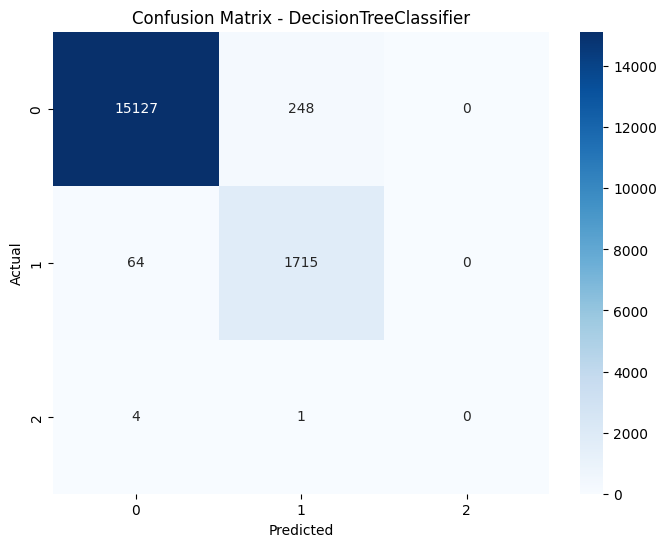

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15375
           1       0.87      0.96      0.92      1779
           2       0.00      0.00      0.00         5

    accuracy                           0.98     17159
   macro avg       0.62      0.65      0.64     17159
weighted avg       0.98      0.98      0.98     17159

Multi-class AUC (OVR): 0.99

Evaluating RandomForestClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


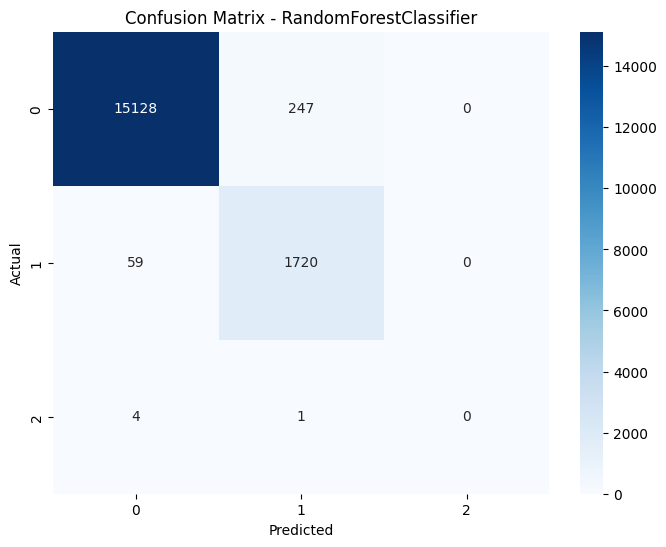

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15375
           1       0.87      0.97      0.92      1779
           2       0.00      0.00      0.00         5

    accuracy                           0.98     17159
   macro avg       0.62      0.65      0.64     17159
weighted avg       0.98      0.98      0.98     17159

Multi-class AUC (OVR): 0.99

Evaluating LogisticRegression...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/u

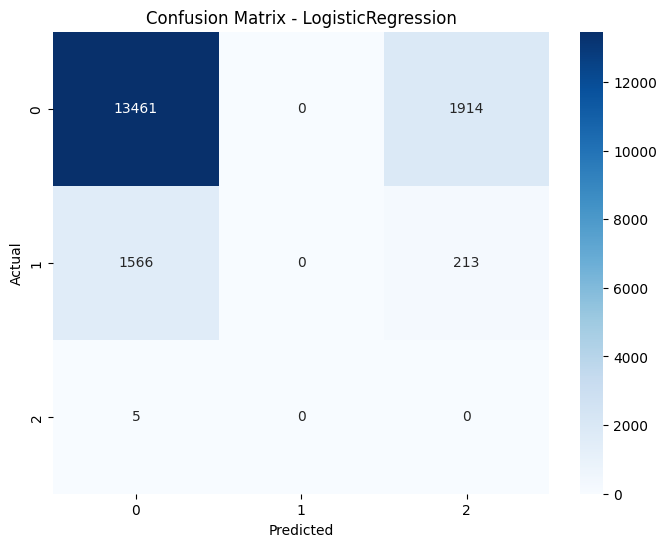

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     15375
           1       0.00      0.00      0.00      1779
           2       0.00      0.00      0.00         5

    accuracy                           0.78     17159
   macro avg       0.30      0.29      0.30     17159
weighted avg       0.80      0.78      0.79     17159

Multi-class AUC (OVR): 0.48

Evaluating KNeighborsClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/u

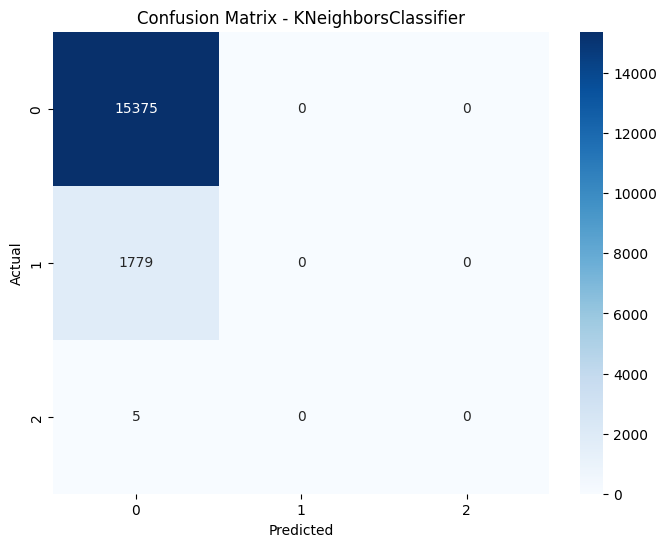

Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     15375
           1       0.00      0.00      0.00      1779
           2       0.00      0.00      0.00         5

    accuracy                           0.90     17159
   macro avg       0.30      0.33      0.32     17159
weighted avg       0.80      0.90      0.85     17159



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/u

Multi-class AUC (OVR): 0.50

Best Model: DecisionTreeClassifier with AUC = 0.99

Final Classification Report for Best Model (DecisionTreeClassifier):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15375
           1       0.87      0.96      0.92      1779
           2       0.00      0.00      0.00         5

    accuracy                           0.98     17159
   macro avg       0.62      0.65      0.64     17159
weighted avg       0.98      0.98      0.98     17159



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Lấy danh sách các lớp (unique values) được sắp xếp theo thứ tự
    classes = sorted(np.unique(y_test))

    # Ma trận nhầm lẫn với nhãn là các lớp
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {type(model).__name__}')
    plt.show()

    # Báo cáo phân loại: precision, recall, f1-score, support
    print(f'Classification Report for {type(model).__name__}:')
    print(classification_report(y_test, y_pred))

    # Tính ROC & AUC
    # Với bài toán đa lớp, ta tính AUC theo phương pháp one-vs-rest (OVR)
    if len(classes) == 2:
        # Trường hợp nhị phân, vẽ ROC curve
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
        auc_score = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {type(model).__name__}')
        plt.legend()
        plt.show()
    else:
        # Với đa lớp, chỉ tính AUC (không vẽ ROC curve cho tất cả các lớp vì quá phức tạp)
        auc_score = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
        print(f'Multi-class AUC (OVR): {auc_score:.2f}')

    return auc_score

# Đánh giá tất cả các mô hình
models = [best_dt_model, best_rf_model, best_lr_model, best_knn_model]  # Giả định các mô hình đã huấn luyện
model_scores = {}

for model in models:
    print(f'\nEvaluating {type(model).__name__}...')
    auc = evaluate_model(model, X_test, y_test)
    model_scores[type(model).__name__] = auc

best_model_name = max(model_scores, key=model_scores.get)
best_model = next(m for m in models if type(m).__name__ == best_model_name)

print(f'\nBest Model: {best_model_name} with AUC = {model_scores[best_model_name]:.2f}')

# Chạy dữ liệu trên mô hình tối ưu nhất
y_final_pred = best_model.predict(X_test)
final_report = classification_report(y_test, y_final_pred)
print(f'\nFinal Classification Report for Best Model ({best_model_name}):')
print(final_report)


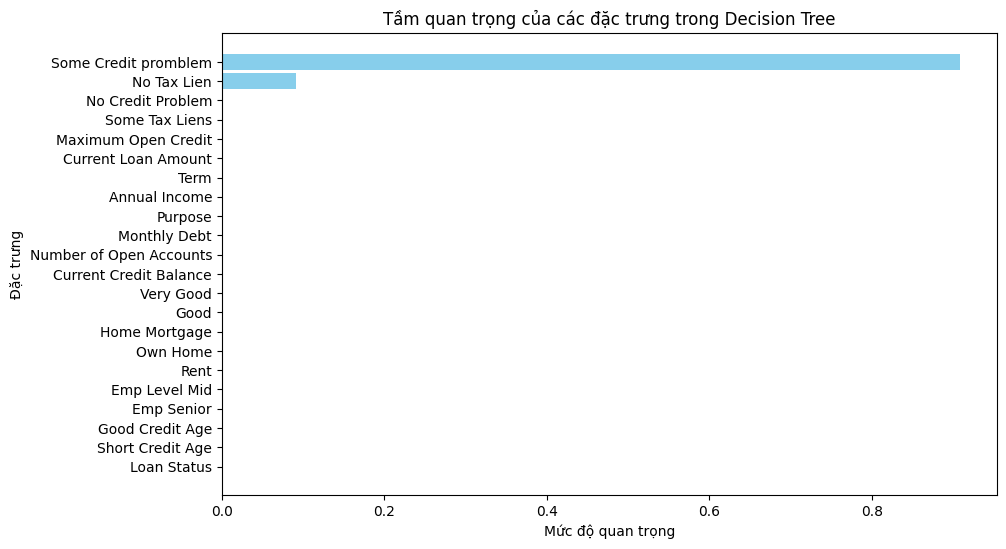

In [ ]:
feature_importances = best_dt_model.feature_importances_
# Sắp xếp các đặc trưng theo mức độ quan trọng
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = X_train.columns[sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='skyblue')
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Đặc trưng")
plt.title("Tầm quan trọng của các đặc trưng trong Decision Tree")
plt.gca().invert_yaxis()
plt.show()

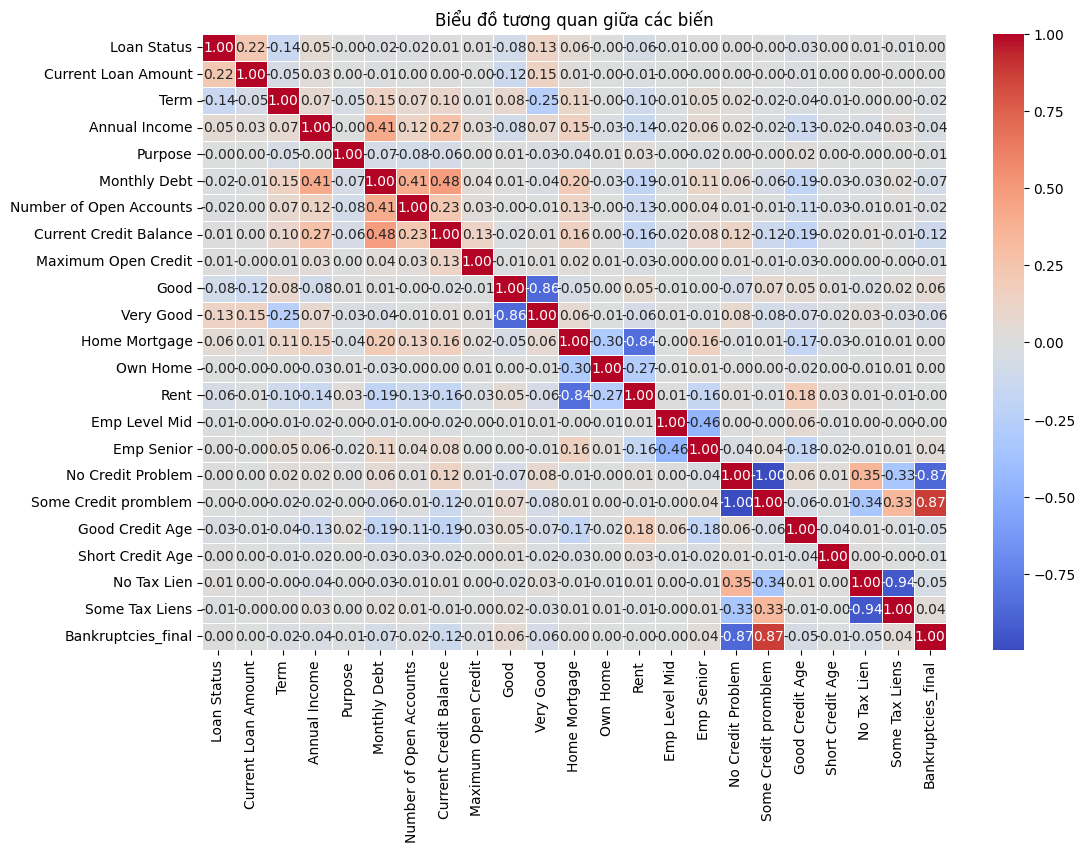

In [ ]:
# Tính ma trận tương quan
correlation_matrix = dataframe.corr()

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Biểu đồ tương quan giữa các biến")
plt.show()